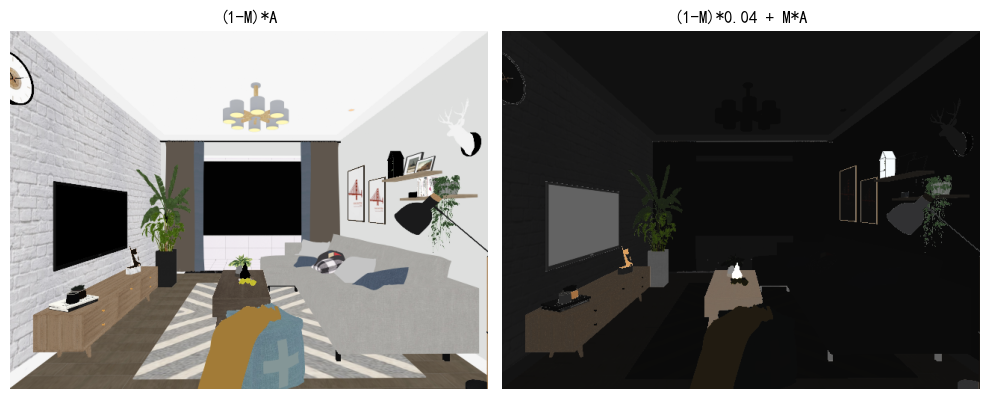

In [10]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

# 读取图片
A = np.array(Image.open('/home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/000_albedo.png')).astype(np.float32) / 255.0
M = np.array(Image.open('/home/jiahao/ipsm_relighting_v2/datasets/interiorverse/scene_0_bp/images/000_material_metal.png')).astype(np.float32) / 255.0

# 如果M是单通道，扩展为3通道
if M.ndim == 2:
    M = np.expand_dims(M, axis=-1)
if M.shape[-1] == 1 and A.shape[-1] == 3:
    M = np.repeat(M, 3, axis=-1)

# 计算结果
img1 = (1 - M) * A
img2 = (1 - M) * 0.04 + M * A

# 可视化
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.clip(img1, 0, 1))
plt.title('(1-M)*A')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.clip(img2, 0, 1))
plt.title('(1-M)*0.04 + M*A')
plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置中文字体（可选）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 定义一些常量
PI = np.pi

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

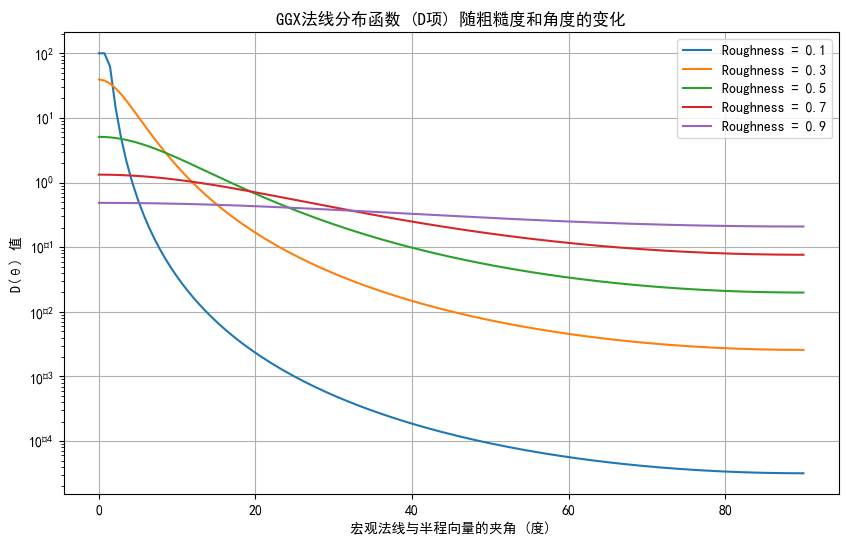

In [4]:
def D_GGX(n_dot_h, roughness):
    """
    计算GGX法线分布函数
    Args:
        n_dot_h: 宏观法线n与半程向量h的点积 (cosθ)
        roughness: 粗糙度 [0,1]
    Returns:
        D值
    """
    a = roughness * roughness
    a2 = a * a
    n_dot_h2 = n_dot_h * n_dot_h

    denom = n_dot_h2 * (a2 - 1.0) + 1.0
    denom = PI * denom * denom

    return a2 / max(denom, 1e-6) # 避免除零

# 可视化不同粗糙度下D项随角度的变化
angles = np.linspace(0, PI/2, 128) # 从0度到90度
n_dot_h = np.cos(angles) # cosθ从1到0

roughness_values = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(10, 6))
for roughness in roughness_values:
    D_values = [D_GGX(ndh, roughness) for ndh in n_dot_h]
    plt.plot(np.degrees(angles), D_values, label=f'Roughness = {roughness}')

plt.xlabel('宏观法线与半程向量的夹角 (度)')
plt.ylabel('D(θ) 值')
plt.title('GGX法线分布函数 (D项) 随粗糙度和角度的变化')
plt.legend()
plt.yscale('log') # 使用对数坐标以便观察
plt.grid(True)
plt.show()

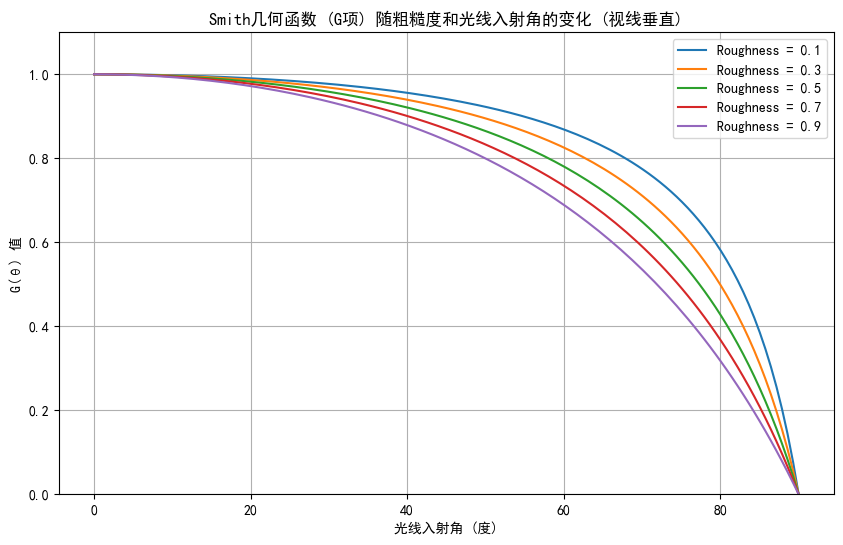

In [6]:
def G_SchlickGGX(n_dot_v, k):
    """
    Schlick-GGX几何遮蔽/遮挡项
    Args:
        n_dot_v: 法线n与视线v（或光线l）的点积
        k: 基于粗糙度的重映射参数，k = (roughness^2)/2 用于直接光
    """
    return n_dot_v / (n_dot_v * (1 - k) + k)

def G_Smith(n_dot_v, n_dot_l, roughness):
    """
    Smith几何函数，结合了视线和光线两部分的遮挡和遮蔽
    """
    k = (roughness + 1) * (roughness + 1) / 8.0 # 对于IBL有不同k值，此处用直接光公式
    return G_SchlickGGX(n_dot_v, k) * G_SchlickGGX(n_dot_l, k)

# 可视化G项随入射角的变化（假设视线方向固定，例如垂直入射 n_dot_v=1.0）
n_dot_v = 1.0 # 视线垂直表面
light_angles = np.linspace(0, PI/2, 128)
n_dot_l = np.cos(light_angles) # 光线入射角的余弦

plt.figure(figsize=(10, 6))
for roughness in roughness_values:
    G_values = [G_Smith(n_dot_v, ndl, roughness) for ndl in n_dot_l]
    plt.plot(np.degrees(light_angles), G_values, label=f'Roughness = {roughness}')

plt.xlabel('光线入射角 (度)')
plt.ylabel('G(θ) 值')
plt.title('Smith几何函数 (G项) 随粗糙度和光线入射角的变化 (视线垂直)')
plt.legend()
plt.grid(True)
plt.ylim(0, 1.1)
plt.show()

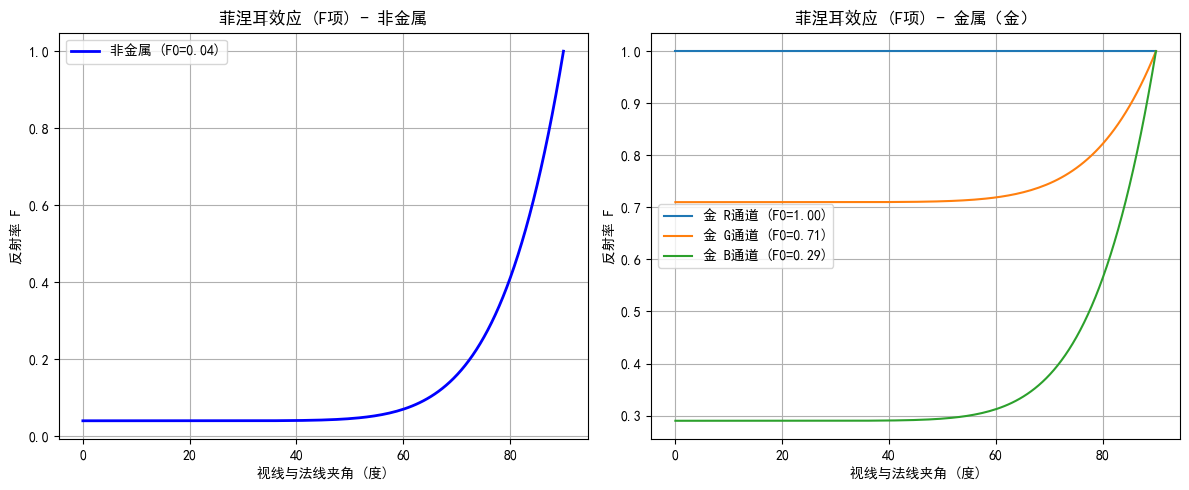

In [8]:
def F_Schlick(n_dot_v, F0):
    """
    菲涅耳方程的Schlick近似
    Args:
        n_dot_v: 法线n与视线v的点积 (这里也可用n_dot_h，但常用n_dot_v)
        F0: 0度入射时的基础反射率
    Returns:
        反射率F
    """
    return F0 + (1.0 - F0) * (1.0 - n_dot_v) ** 5

# 可视化F项随视线角度的变化（对于不同F0的材质）
view_angles = np.linspace(0, PI/2, 128)
n_dot_v = np.cos(view_angles)

# 定义几种典型材质的F0
F0_dielectric = 0.04 # 常见电介质（塑料、木材）
F0_gold = np.array([1.0, 0.71, 0.29]) # 金的F0 (RGB)

plt.figure(figsize=(12, 5))

# 绘制非金属
plt.subplot(1, 2, 1)
F_dielectric = [F_Schlick(ndv, F0_dielectric) for ndv in n_dot_v]
plt.plot(np.degrees(view_angles), F_dielectric, 'b-', label=f'非金属 (F0={F0_dielectric})', linewidth=2)
plt.xlabel('视线与法线夹角 (度)')
plt.ylabel('反射率 F')
plt.title('菲涅耳效应 (F项) - 非金属')
plt.legend()
plt.grid(True)

# 绘制金属（分RGB通道）
plt.subplot(1, 2, 2)
for i, color in enumerate(['R', 'G', 'B']):
    F_metal = [F_Schlick(ndv, F0_gold[i]) for ndv in n_dot_v]
    plt.plot(np.degrees(view_angles), F_metal, label=f'金 {color}通道 (F0={F0_gold[i]:.2f})')

plt.xlabel('视线与法线夹角 (度)')
plt.ylabel('反射率 F')
plt.title('菲涅耳效应 (F项) - 金属（金）')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

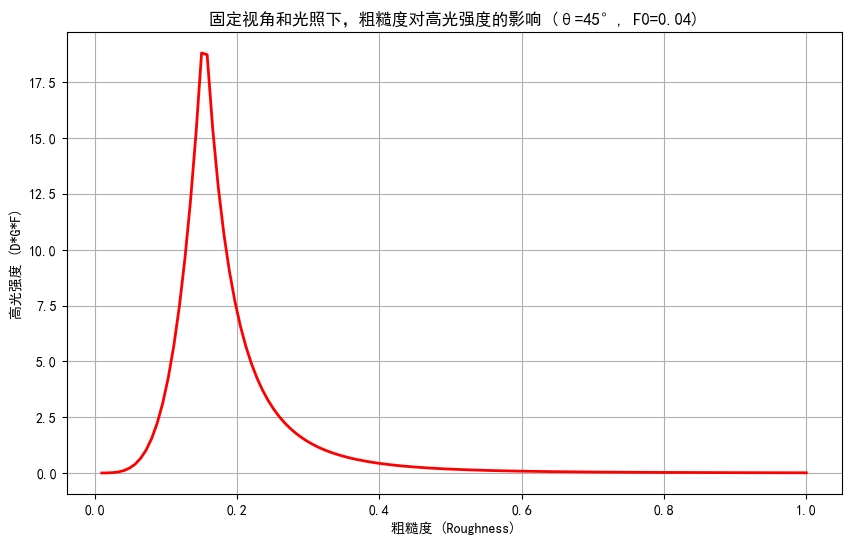

In [9]:
def cook_torrance_specular(n_dot_v, n_dot_l, n_dot_h, roughness, F0):
    """计算Cook-Torrance BRDF的镜面反射部分（D*G*F）"""
    D = D_GGX(n_dot_h, roughness)
    G = G_Smith(n_dot_v, n_dot_l, roughness)
    F = F_Schlick(n_dot_v, F0) # 通常用n_dot_v或n_dot_l做菲涅耳近似
    return D * G * F

# 假设一个固定的光照和视线设置
# 例如：视线和光线关于法线对称，夹角均为45度。此时半程向量h与法线n重合。
theta = np.radians(45) # 45度角
n_dot_v = np.cos(theta)
n_dot_l = np.cos(theta)
n_dot_h = 1.0 # 因为h和n重合

F0 = 0.04 # 使用非金属的F0

# 生成一系列粗糙度值
roughness_range = np.linspace(0.01, 1.0, 128)
specular_values = [cook_torrance_specular(n_dot_v, n_dot_l, n_dot_h, r, F0) for r in roughness_range]

plt.figure(figsize=(10, 6))
plt.plot(roughness_range, specular_values, 'r-', linewidth=2)
plt.xlabel('粗糙度 (Roughness)')
plt.ylabel('高光强度 (D*G*F)')
plt.title('固定视角和光照下，粗糙度对高光强度的影响 (θ=45°, F0=0.04)')
plt.grid(True)
# plt.yscale('log') # 可以尝试用对数坐标观察
plt.show()